# IT3091 Machine Learning Group Assignment
## Project Title: HDFC Bank Stock Price Movement Prediction Using Historical Market Data
### Track: Industry Explorer (Investment Decision Support Lens) | 4-Member Group Project

---

### Group Member Contribution Architecture:
- **Member 1 (Lead: Data Acquisition, Cleaning & Exploratory Data Analysis):** Raw market data ingestion, schema validation, zero-volume handling, return distribution analysis, and volatility regime profiling.
- **Member 2 (Lead: Feature Engineering & Preprocessing Pipeline):** Computation of 34 technical indicators (Momentum, Moving Averages, Oscillators, Volatility, Volume), target creation ($y_t$), chronological train/val/test splitting, and zero-leakage standard scaling.
- **Member 3 (Lead: Supervised Classification Suite & Model Training):** Implementation of rule-based baseline (Naive Momentum) and 4 supervised models (Logistic Regression, Random Forest, HistGradientBoosting, Support Vector Classifier), and validation set hyperparameter tuning.
- **Member 4 (Lead: Model Evaluation, Explainability & Decision Support Backtest):** Rigorous out-of-sample test evaluation, ROC-AUC comparison, confusion matrices, Random Forest feature importance analysis, and investment decision support backtesting simulation with transaction costs.


---
# Part 1: Data Acquisition, Cleaning & Exploratory Data Analysis (Member 1 Lead)

### 1.1 Context & Business Problem Framing
Financial institutions, portfolio managers, and retail investors face substantial uncertainty when assessing short-term equity price movements. In the Indian equity market, HDFC Bank (NSE: `HDFCBANK.NS`) is the largest private sector bank and a heavyweight constituent in the NIFTY 50 and NIFTY Bank indices. 

The objective of this project is to develop a robust supervised machine learning pipeline to forecast the **next-trading-day price movement direction** (Binary Classification: $y_t \in \{0, 1\}$).

Under our primary lens (**Investment Decision Support**), the ML system functions not as an autonomous execution black-box, but as a systematic directional filter to reduce downside exposure and optimize capital allocation.


In [1]:
import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure environment and seed
ROOT_DIR = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.utils import set_seed, setup_plotting_style, FEATURE_COLUMNS, TARGET_COLUMN

# Dynamic module loading for numbered filenames
c1 = importlib.import_module('src.01_data_cleaning_and_eda')
c2 = importlib.import_module('src.02_feature_engineering')
c3 = importlib.import_module('src.03_model_training')
c4 = importlib.import_module('src.04_evaluation')

set_seed(42)
setup_plotting_style()
print(f"Working Directory: {ROOT_DIR}")


Working Directory: c:\Users\moham\Downloads\Machine Learning


### 1.2 Data Loading & Cleaning
The raw dataset contains daily trading data spanning over 30 years (1996 - 2026). The raw CSV contains multi-row headers and ticker metadata from Yahoo Finance which requires structural parsing and cleanup.


In [2]:
# Load and clean raw HDFC Bank historical dataset
cleaned_df = c1.load_and_clean_raw_data()
cleaned_df.head()


COMPONENT 1: DATA CLEANING & EXPLORATORY DATA ANALYSIS (EDA)

Successfully cleaned 7,709 trading sessions from 1996-01-01 to 2026-09-11.
Cleaned dataset saved: c:\Users\moham\Downloads\Machine Learning\data\processed\hdfc_cleaned.csv



,Date,Adj_Close,Close,High,Low,Open,Volume,daily_return,log_return
0,1996-01-01,1.131260,1.4900,1.5150,1.4625,1.5150,700000.0,NaN,NaN
1,1996-01-02,1.129362,1.4875,1.5125,1.4750,1.4900,824000.0,-0.001678,-0.001679
2,1996-01-03,1.133158,1.4925,1.4975,1.4750,1.4875,568000.0,0.003361,0.003356
3,1996-01-04,1.125566,1.4825,1.4900,1.4700,1.4925,564000.0,-0.006700,-0.006723
4,1996-01-05,1.123667,1.4800,1.4900,1.4750,1.4825,378000.0,-0.001686,-0.001688


### 1.3 Statistical Profiling & Exploratory Data Analysis
Let's inspect the statistical characteristics of daily simple returns and examine the distribution properties (fat tails, skewness, excess kurtosis).


In [3]:
summary_df = c1.generate_eda_visualizations_and_summary(cleaned_df)
summary_df


Generating EDA visualization figures...


EDA figures generated in reports/figures/
EDA summary stats saved: c:\Users\moham\Downloads\Machine Learning\reports\eda_summary_statistics.csv



,Metric,Value
0,Total Trading Sessions,"7,709"
1,Start Date,1996-01-01
2,End Date,2026-09-11
3,Mean Daily Return (%),0.1010%
4,Annualized Return (%),28.97%
5,Daily Volatility (%),2.0580%
6,Annualized Volatility (%),32.67%
7,Skewness,0.7084
8,Excess Kurtosis,9.9429
9,Max Single-Day Gain (%),25.82% (on 2004-05-18)


### 1.4 Visualizing EDA Figures
Displaying the generated EDA figures: Historical Price/Volume, Return Distribution, Volatility Regimes, and Correlation Heatmap.


Displaying: reports/figures/01_eda_price_volume_history.png


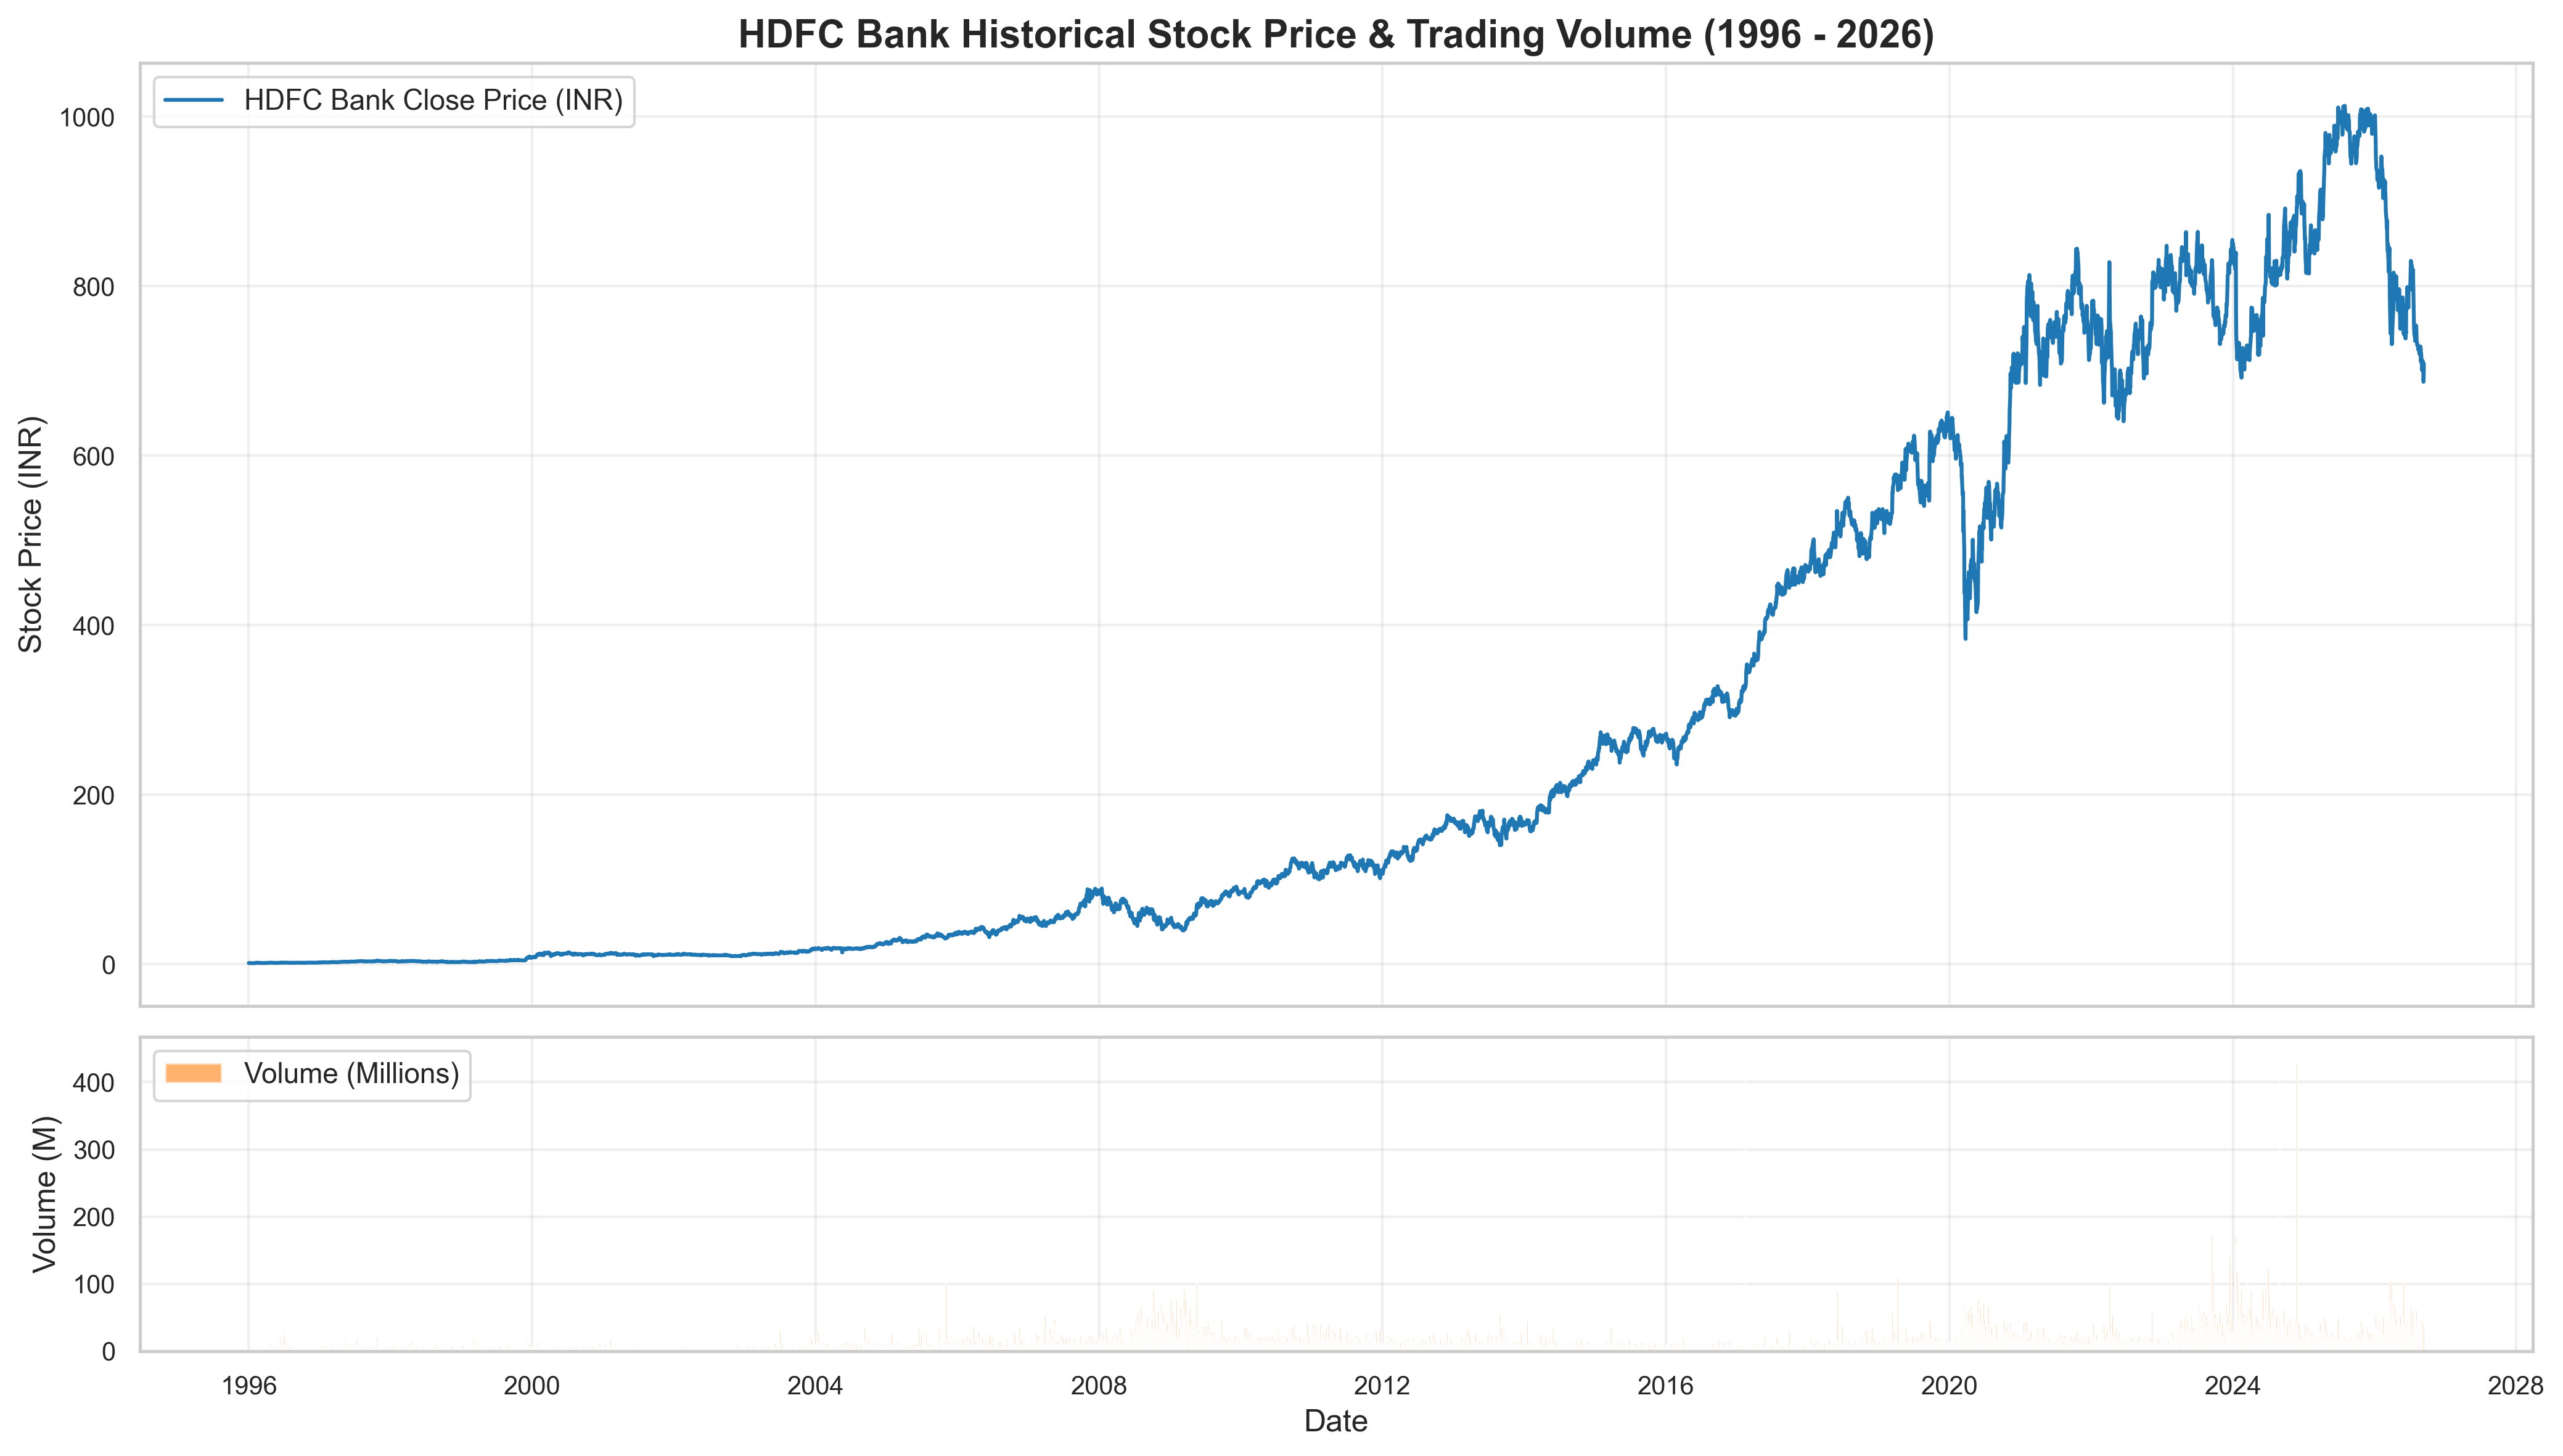

Displaying: reports/figures/02_eda_return_distribution.png


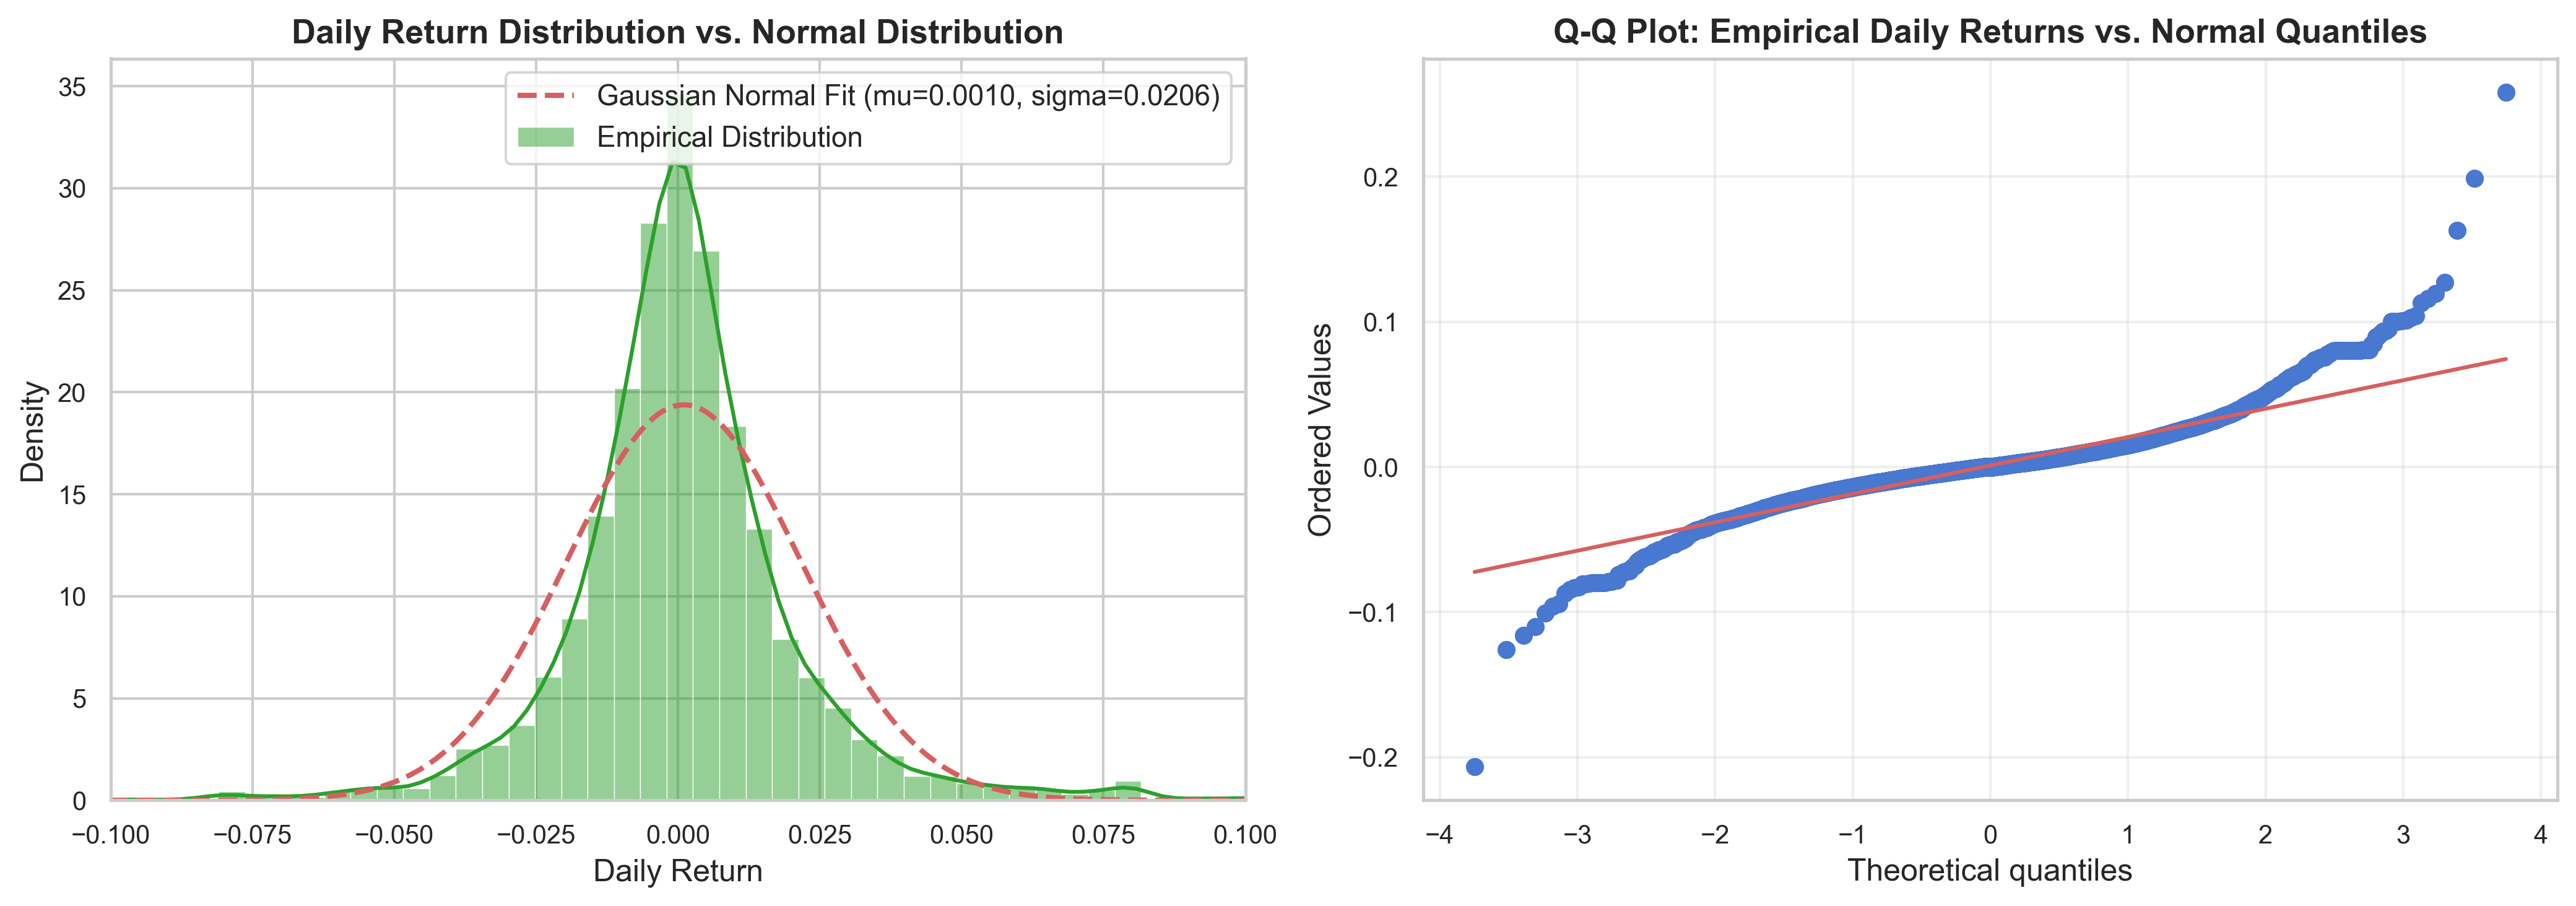

Displaying: reports/figures/03_eda_volatility_regimes.png


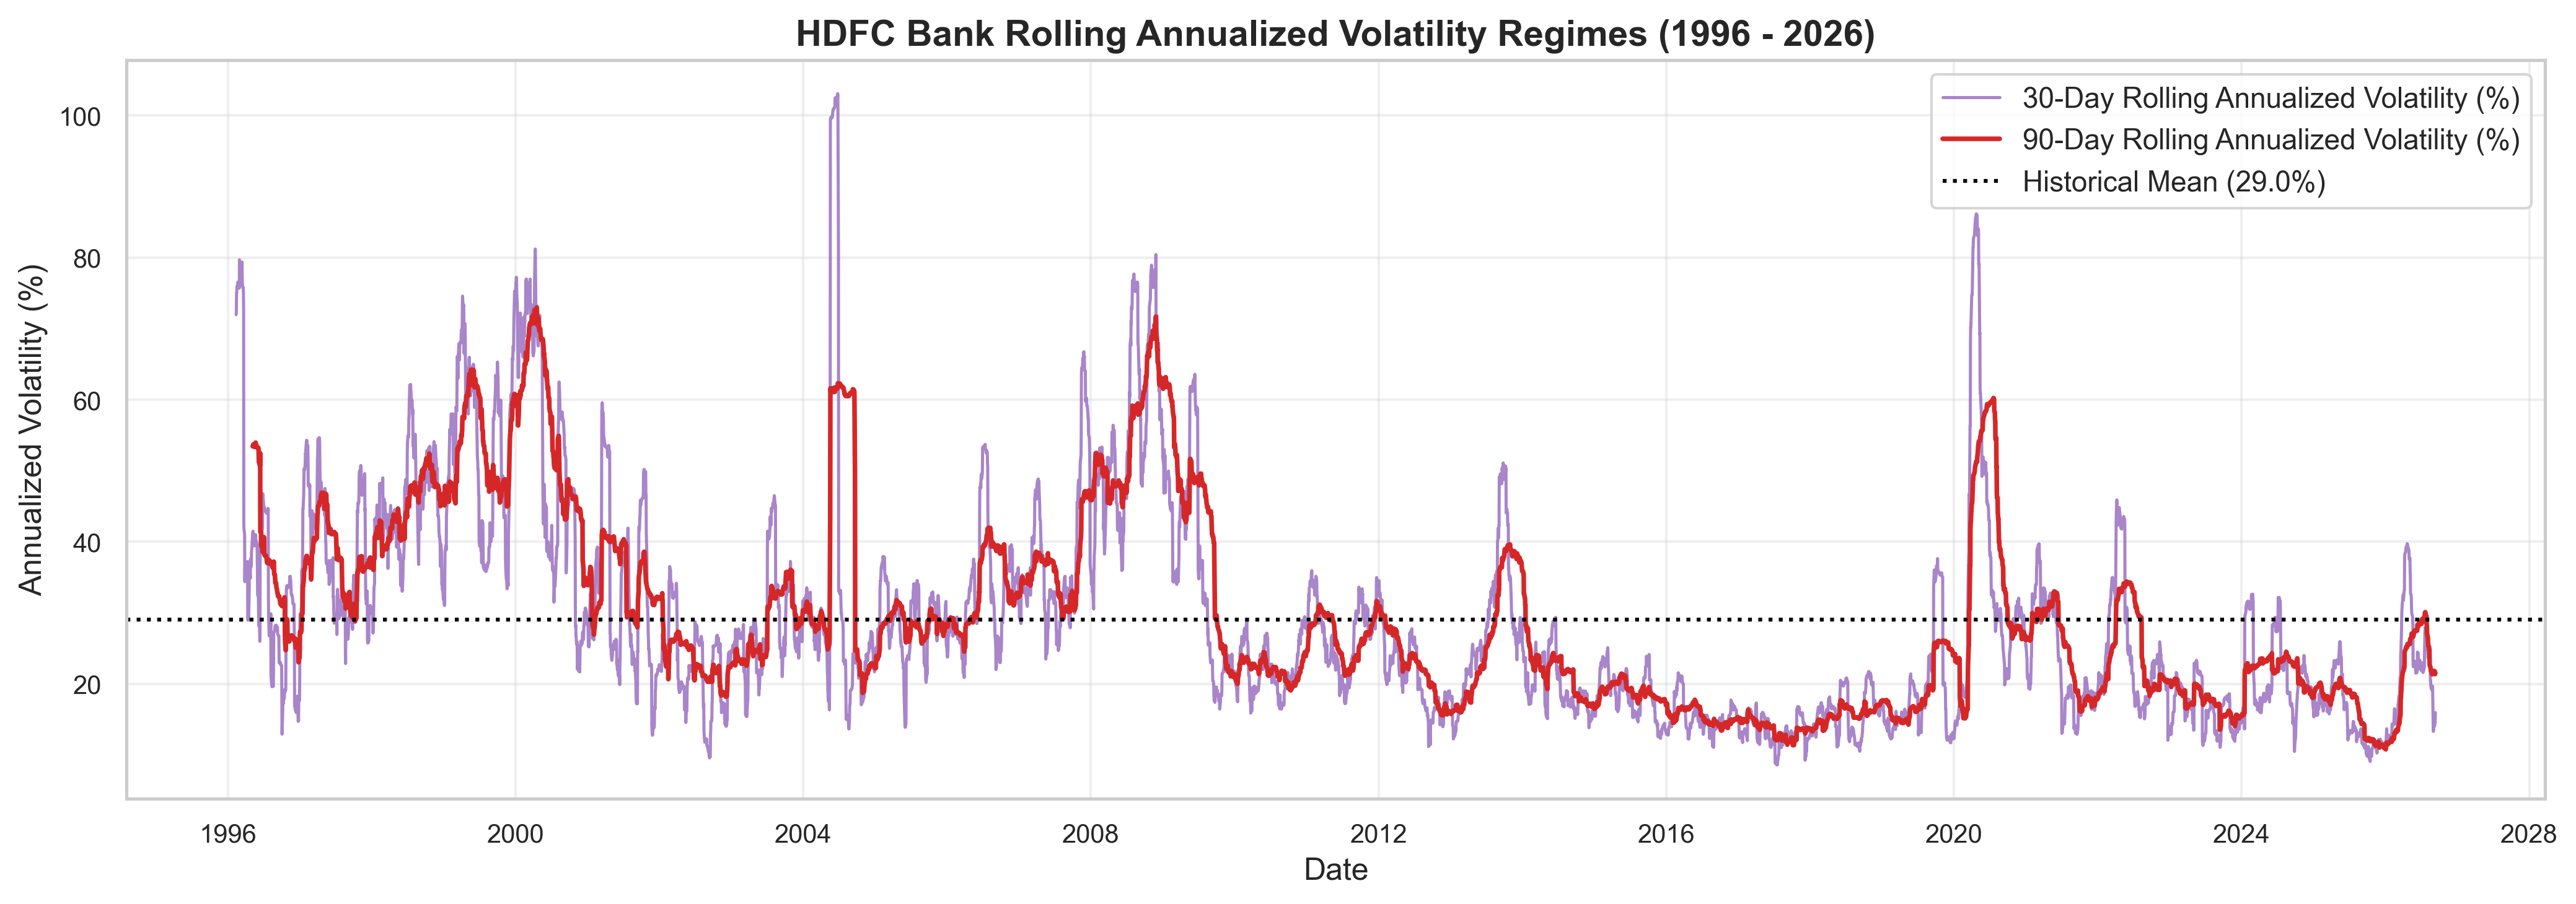

Displaying: reports/figures/04_eda_correlation_heatmap.png


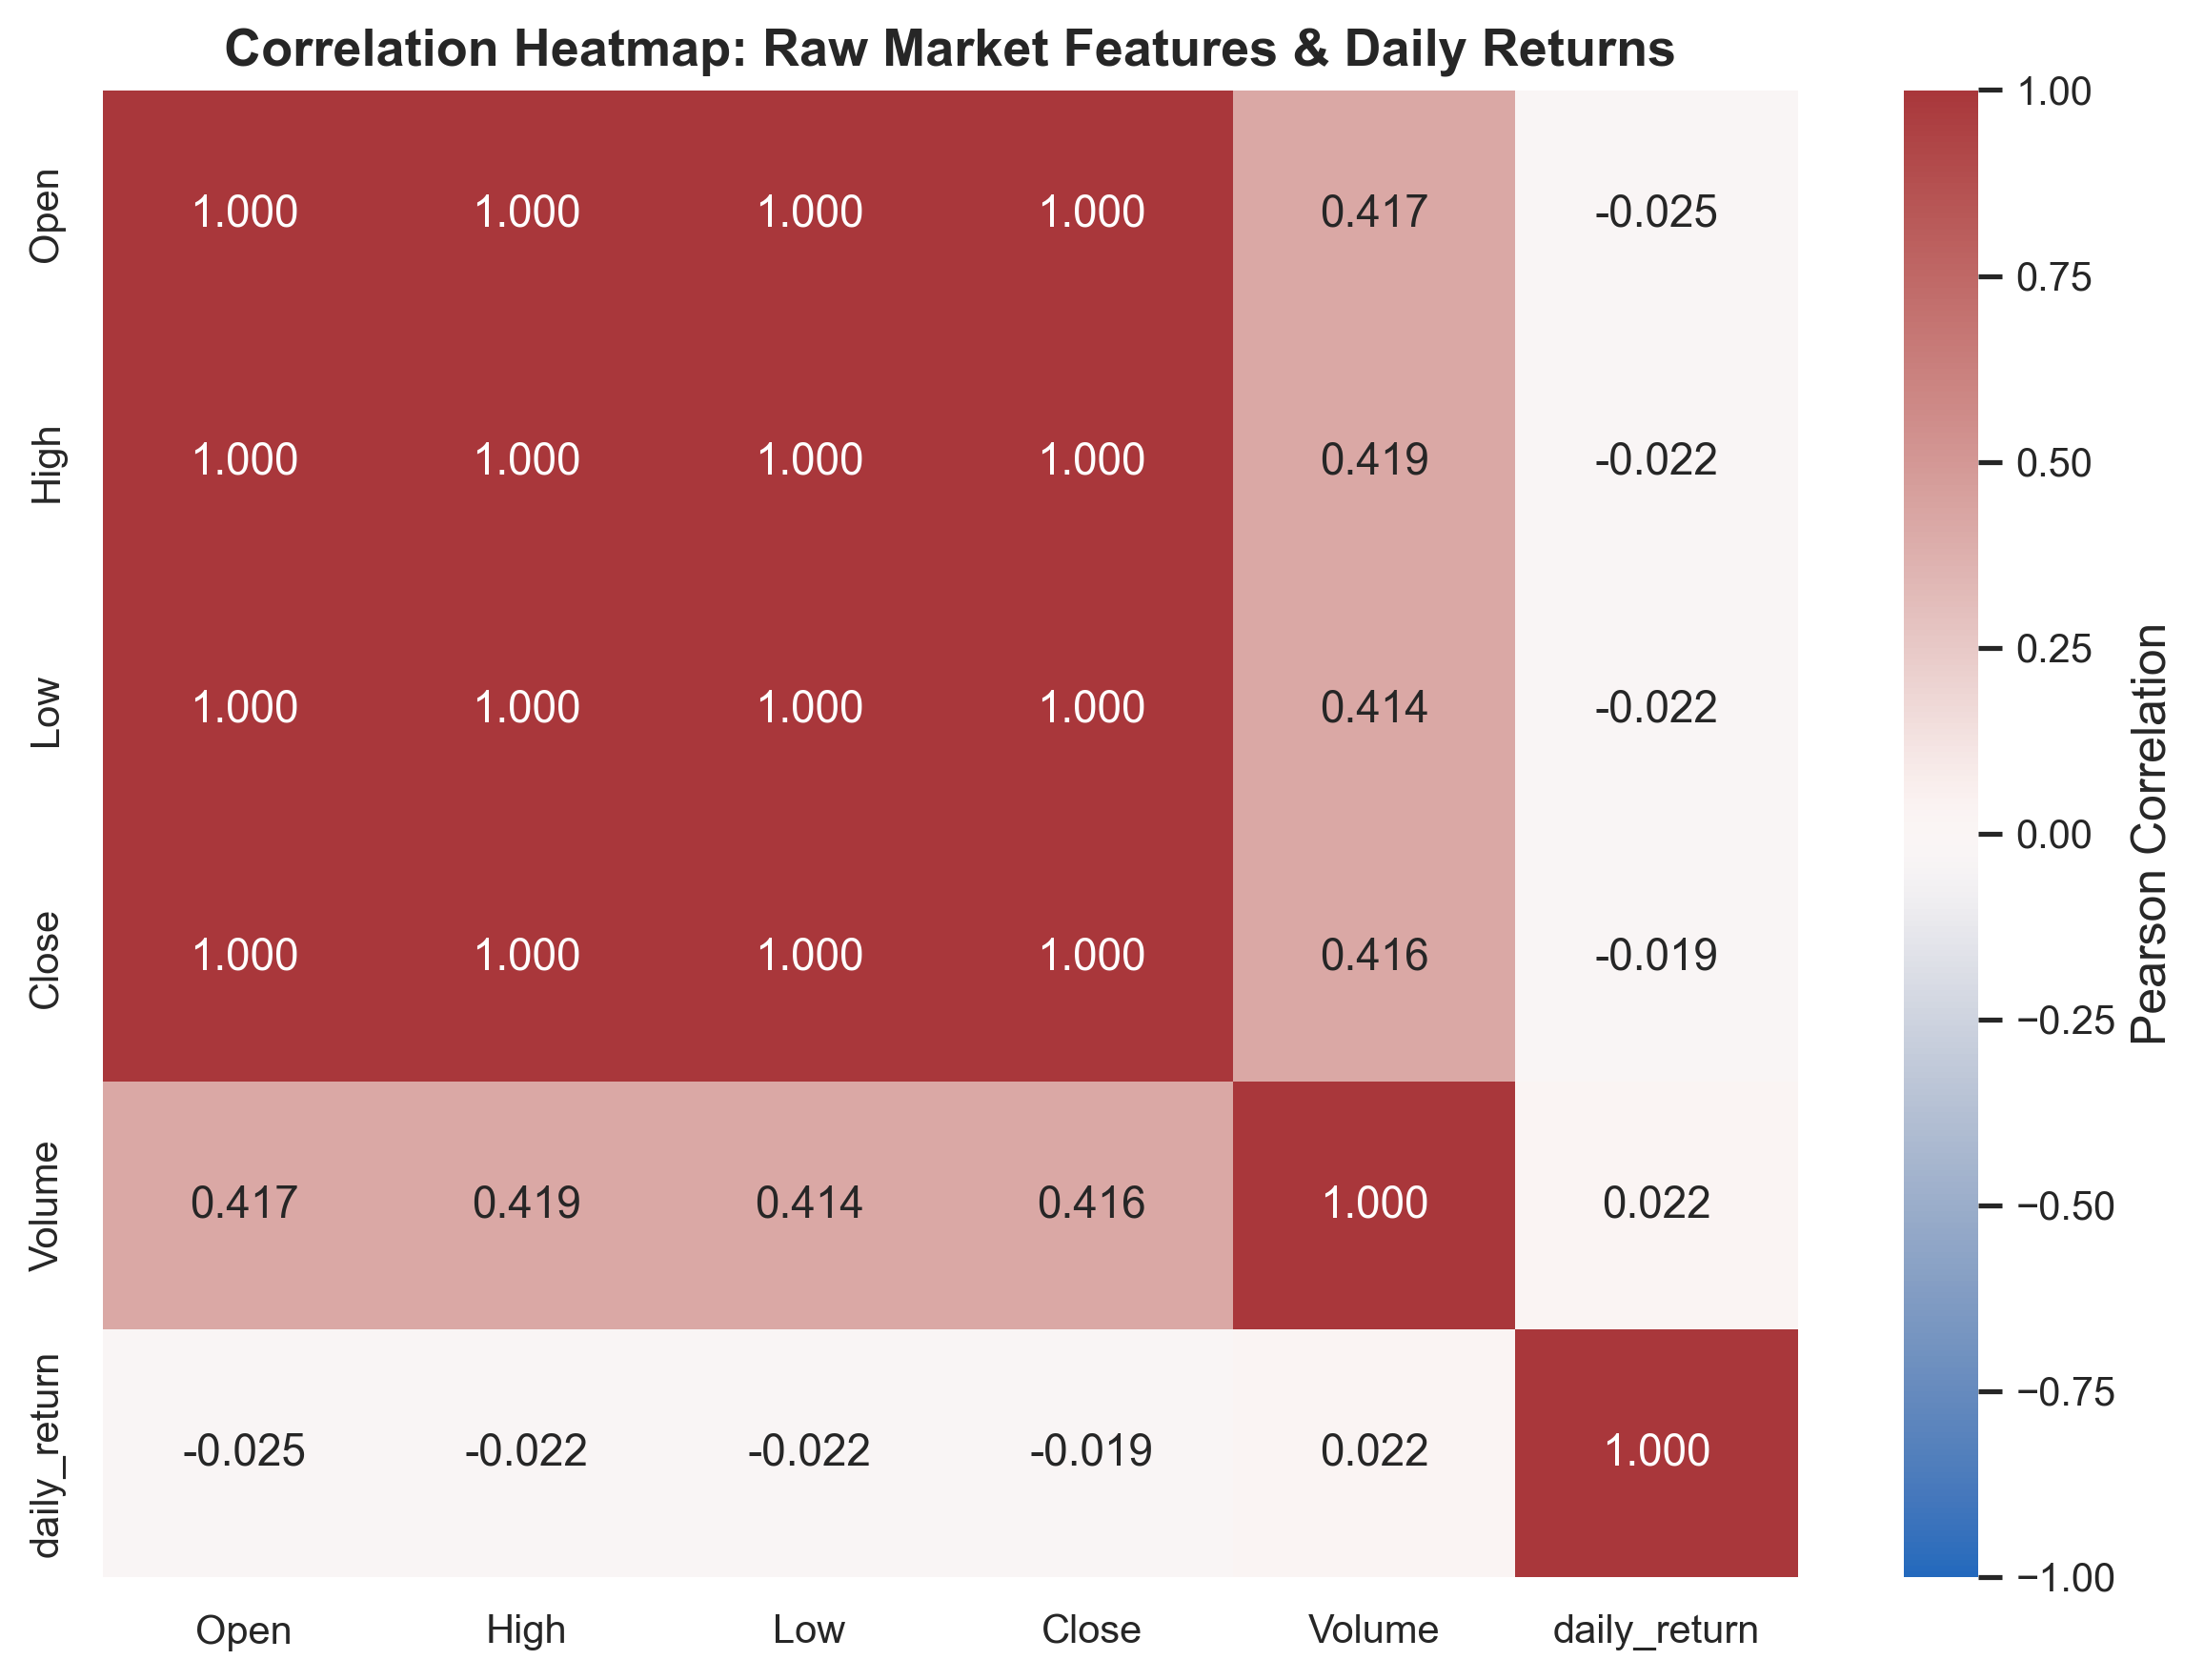

In [4]:
from IPython.display import Image, display

eda_figures = [
    'reports/figures/01_eda_price_volume_history.png',
    'reports/figures/02_eda_return_distribution.png',
    'reports/figures/03_eda_volatility_regimes.png',
    'reports/figures/04_eda_correlation_heatmap.png'
]

for fig_path in eda_figures:
    full_path = os.path.join(ROOT_DIR, fig_path)
    if os.path.exists(full_path):
        print(f"Displaying: {fig_path}")
        display(Image(filename=full_path))


---
# Part 2: Feature Engineering & Temporal Data Splitting (Member 2 Lead)

### 2.1 Technical Indicators Formulation
To forecast $y_t = \mathbb{I}(\text{Close}_{t+1} > \text{Close}_t)$, we construct 34 domain-informed technical features using strictly information available at or before trading day $t$:
1. **Price Momentum & Lagged Returns:** 1-day, 2-day, 3-day, 5-day, 10-day, and 20-day returns.
2. **Trend & Moving Average Ratios:** $\text{SMA}_w$ and $\text{EMA}_w$ ratios ($w \in \{5, 10, 20, 50, 200\}$) and Golden/Death cross proxies ($\text{SMA}_{5}/\text{SMA}_{20}$ and $\text{SMA}_{50}/\text{SMA}_{200}$).
3. **Oscillators:** Relative Strength Index ($\text{RSI}_{14}$), Moving Average Convergence Divergence ($\text{MACD}$ line, signal, difference), and Stochastic $\%K_{14}$ / $\%D_3$.
4. **Volatility & Intraday Action:** 20-day annualized rolling volatility ($\sigma_{20} \times \sqrt{252}$), Average True Range ratio ($\text{ATR}_{14}/\text{Close}$), Bollinger Bands $\%B$ and Bandwidth, High-Low spread, and Overnight Gap.
5. **Volume Indicators:** 1-day volume change, and volume-to-moving-average ratios ($\text{SMA}_5$, $\text{SMA}_{20}$).
6. **Calendar Seasonality:** Day of week, month, and calendar quarter.

### 2.2 Temporal Leakage Prevention
Financial time series violate the IID (independent and identically distributed) assumption. Standard random k-fold cross-validation results in severe lookahead leakage. Therefore:
- **Chronological Split:** Train (70%: 1996 - 2017), Validation (15%: 2017 - 2022), Test (15%: 2022 - 2026).
- **Leakage-Free Scaling:** `StandardScaler` is fitted **strictly on the training partition** and then applied to transform Validation and Test partitions.


In [5]:
# Execute feature engineering and chronological data splitting
train_df, val_df, test_df, scaler, feature_cols = c2.prepare_and_split_data()
print(f"Number of engineered features: {len(feature_cols)}")
train_df[feature_cols].head(3)


COMPONENT 2: FEATURE ENGINEERING & DATA SPLITTING

Total valid samples: 7508 (from 1996-10-07 to 2026-09-10)
Train set:       5255 samples (1996-10-07 to 2017-08-02)
Validation set:  1126 samples (2017-08-03 to 2022-02-22)
Test set:        1127 samples (2022-02-23 to 2026-09-10)

Class balance (Target = 1 [UP] %):
  Train:      49.19%
  Validation: 50.98%
  Test:       50.22%

Scaler fitted strictly on training data and saved to: c:\Users\moham\Downloads\Machine Learning\models\scaler.joblib


Feature datasets saved in: c:\Users\moham\Downloads\Machine Learning\data\processed
Engineered 34 technical features across price, momentum, volatility, and volume.

Number of engineered features: 34


,return_1d,return_2d,return_3d,return_5d,return_10d,return_20d,sma_5_ratio,sma_10_ratio,sma_20_ratio,sma_50_ratio,...,bb_bandwidth,hl_spread,co_spread,overnight_gap,vol_return_1d,vol_sma_5_ratio,vol_sma_20_ratio,day_of_week,month,quarter
0,-0.036313,-0.029536,-0.049587,-0.036313,-0.052198,-0.067568,-0.033343,-0.038997,-0.054341,-0.046830,...,0.082630,0.057971,-0.019886,-0.016760,0.592317,0.429207,0.909858,0,10,4
1,-0.013044,-0.048883,-0.042194,-0.061984,-0.060690,-0.084677,-0.033768,-0.045684,-0.062629,-0.058586,...,0.100090,0.049927,0.030257,-0.042029,-0.389105,-0.051130,0.232387,1,10,4
2,0.014684,0.001449,-0.034916,-0.048209,-0.048209,-0.072483,-0.009745,-0.026898,-0.045316,-0.044419,...,0.106462,0.059334,-0.032213,0.048458,-0.154140,-0.209712,0.084923,2,10,4


---
# Part 3: Model Architecture, Training & Hyperparameter Tuning (Member 3 Lead)

### 3.1 Model Candidate Selection
We evaluate a diverse suite of 5 supervised machine learning models:
1. **Naive Momentum Baseline:** A rule-based financial benchmark predicting $y_t = \mathbb{I}(\text{return\_1d}_t > 0)$.
2. **Regularized Logistic Regression ($L_2$):** Linear probabilistic classifier with inverse regularization $C=0.10$ and balanced class weighting.
3. **Random Forest Classifier:** Non-linear bagging ensemble of 300 decision trees with max depth 6 and min samples per leaf 20 to constrain overfitting.
4. **Histogram-based Gradient Boosting Classifier:** Tree ensemble with learning rate 0.03, max depth 4, and $L_2$ regularization 0.1.
5. **Support Vector Classifier (RBF Kernel):** Maximum-margin kernel classifier ($C=0.5$, $\gamma=\text{scale}$) calibrated with Platt scaling probabilities.

### 3.2 Model Training and Validation Benchmarking


In [6]:
# Train all models and evaluate on validation set
models, val_metrics_df = c3.train_and_validate_models()
val_metrics_df


COMPONENT 3: MODEL TRAINING & HYPERPARAMETER TUNING

Training 5 models on 5255 training sessions...

--> Training [Baseline_Momentum]...
    Validation Accuracy: 49.20% | Macro F1: 0.4918 | ROC-AUC: 0.4925
    Saved model to: c:\Users\moham\Downloads\Machine Learning\models\Baseline_Momentum.joblib
--> Training [Logistic_Regression]...
    Validation Accuracy: 51.51% | Macro F1: 0.4701 | ROC-AUC: 0.5187
    Saved model to: c:\Users\moham\Downloads\Machine Learning\models\Logistic_Regression.joblib
--> Training [Random_Forest]...


    Validation Accuracy: 51.42% | Macro F1: 0.4884 | ROC-AUC: 0.5031
    Saved model to: c:\Users\moham\Downloads\Machine Learning\models\Random_Forest.joblib
--> Training [Hist_Gradient_Boosting]...


    Validation Accuracy: 52.58% | Macro F1: 0.5087 | ROC-AUC: 0.4945
    Saved model to: c:\Users\moham\Downloads\Machine Learning\models\Hist_Gradient_Boosting.joblib
--> Training [Support_Vector_Classifier]...


    Validation Accuracy: 52.75% | Macro F1: 0.5070 | ROC-AUC: 0.5123
    Saved model to: c:\Users\moham\Downloads\Machine Learning\models\Support_Vector_Classifier.joblib

Validation performance summary saved to: c:\Users\moham\Downloads\Machine Learning\reports\validation_metrics.csv



,Model,Accuracy,Macro_F1,ROC_AUC,Precision_UP,Recall_UP,F1_UP,Brier_Score
0,Baseline_Momentum,0.492007,0.491847,0.492542,0.501880,0.465157,0.482821,0.253299
1,Logistic_Regression,0.515098,0.470137,0.518687,0.515909,0.790941,0.624484,0.250309
2,Random_Forest,0.514210,0.488380,0.503118,0.516770,0.724739,0.603336,0.250841
3,Hist_Gradient_Boosting,0.525755,0.508665,0.494499,0.526247,0.698606,0.600299,0.253068
4,Support_Vector_Classifier,0.527531,0.506960,0.512312,0.526854,0.717770,0.607670,0.249971


---
# Part 4: Model Evaluation, Explainability & Decision Support Backtest (Member 4 Lead)

### 4.1 Out-of-Sample Test Evaluation
We evaluate all trained models on the unseen 15% holdout test partition (1,127 trading sessions from February 2022 to September 2026).


In [7]:
# Perform out-of-sample evaluation on holdout test set
test_metrics_df, sim_df = c4.evaluate_models_on_test_set()
test_metrics_df


COMPONENT 4: MODEL EVALUATION, EXPLAINABILITY & DECISION SUPPORT

Evaluating 5 models on 1127 out-of-sample test sessions (2022-02-23 to 2026-09-10)...

--> Baseline_Momentum          | Acc: 51.73% | UP Prec: 52.2% | UP Rec: 46.3% | Macro F1: 0.5160 | ROC-AUC: 0.5175
--> Logistic_Regression        | Acc: 50.75% | UP Prec: 50.5% | UP Rec: 89.4% | Macro F1: 0.4190 | ROC-AUC: 0.4901
--> Random_Forest              | Acc: 50.58% | UP Prec: 50.5% | UP Rec: 78.1% | Macro F1: 0.4642 | ROC-AUC: 0.4915


--> Hist_Gradient_Boosting     | Acc: 50.93% | UP Prec: 50.8% | UP Rec: 71.6% | Macro F1: 0.4868 | ROC-AUC: 0.5080


--> Support_Vector_Classifier  | Acc: 51.82% | UP Prec: 51.3% | UP Rec: 81.8% | Macro F1: 0.4693 | ROC-AUC: 0.4965

Metrics summary saved to: c:\Users\moham\Downloads\Machine Learning\reports\metrics_summary.csv


c:\Users\moham\Downloads\Machine Learning\src\04_evaluation.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='Blues_r', ax=ax)


Running Investment Decision Support Backtest Simulation...
Trading simulation results saved to: c:\Users\moham\Downloads\Machine Learning\reports\trading_simulation_summary.csv


Decision support simulation figure generated: reports/figures/07_decision_support_simulation.png



,Model,Accuracy,Precision_UP,Recall_UP,F1_UP,Precision_DOWN,Recall_DOWN,F1_DOWN,Macro_F1,ROC_AUC,Brier_Score,Log_Loss
0,Baseline_Momentum,0.517303,0.521912,0.462898,0.490637,0.513600,0.572193,0.541315,0.515976,0.517545,0.250770,0.694700
1,Logistic_Regression,0.507542,0.505495,0.893993,0.645820,0.523810,0.117647,0.192140,0.418980,0.490080,0.252619,0.698462
2,Random_Forest,0.505768,0.505143,0.780919,0.613463,0.507937,0.228164,0.314883,0.464173,0.491500,0.251092,0.695340
3,Hist_Gradient_Boosting,0.509317,0.508156,0.715548,0.594277,0.512121,0.301248,0.379349,0.486813,0.508029,0.252232,0.697768
4,Support_Vector_Classifier,0.518190,0.512735,0.818021,0.630361,0.540179,0.215686,0.308280,0.469321,0.496451,0.250890,0.694937


### 4.2 Confusion Matrices & ROC Curves Analysis
Let's inspect the classification diagnostics including confusion matrices and ROC curves across all models.


Displaying: reports/figures/05_model_roc_comparison.png


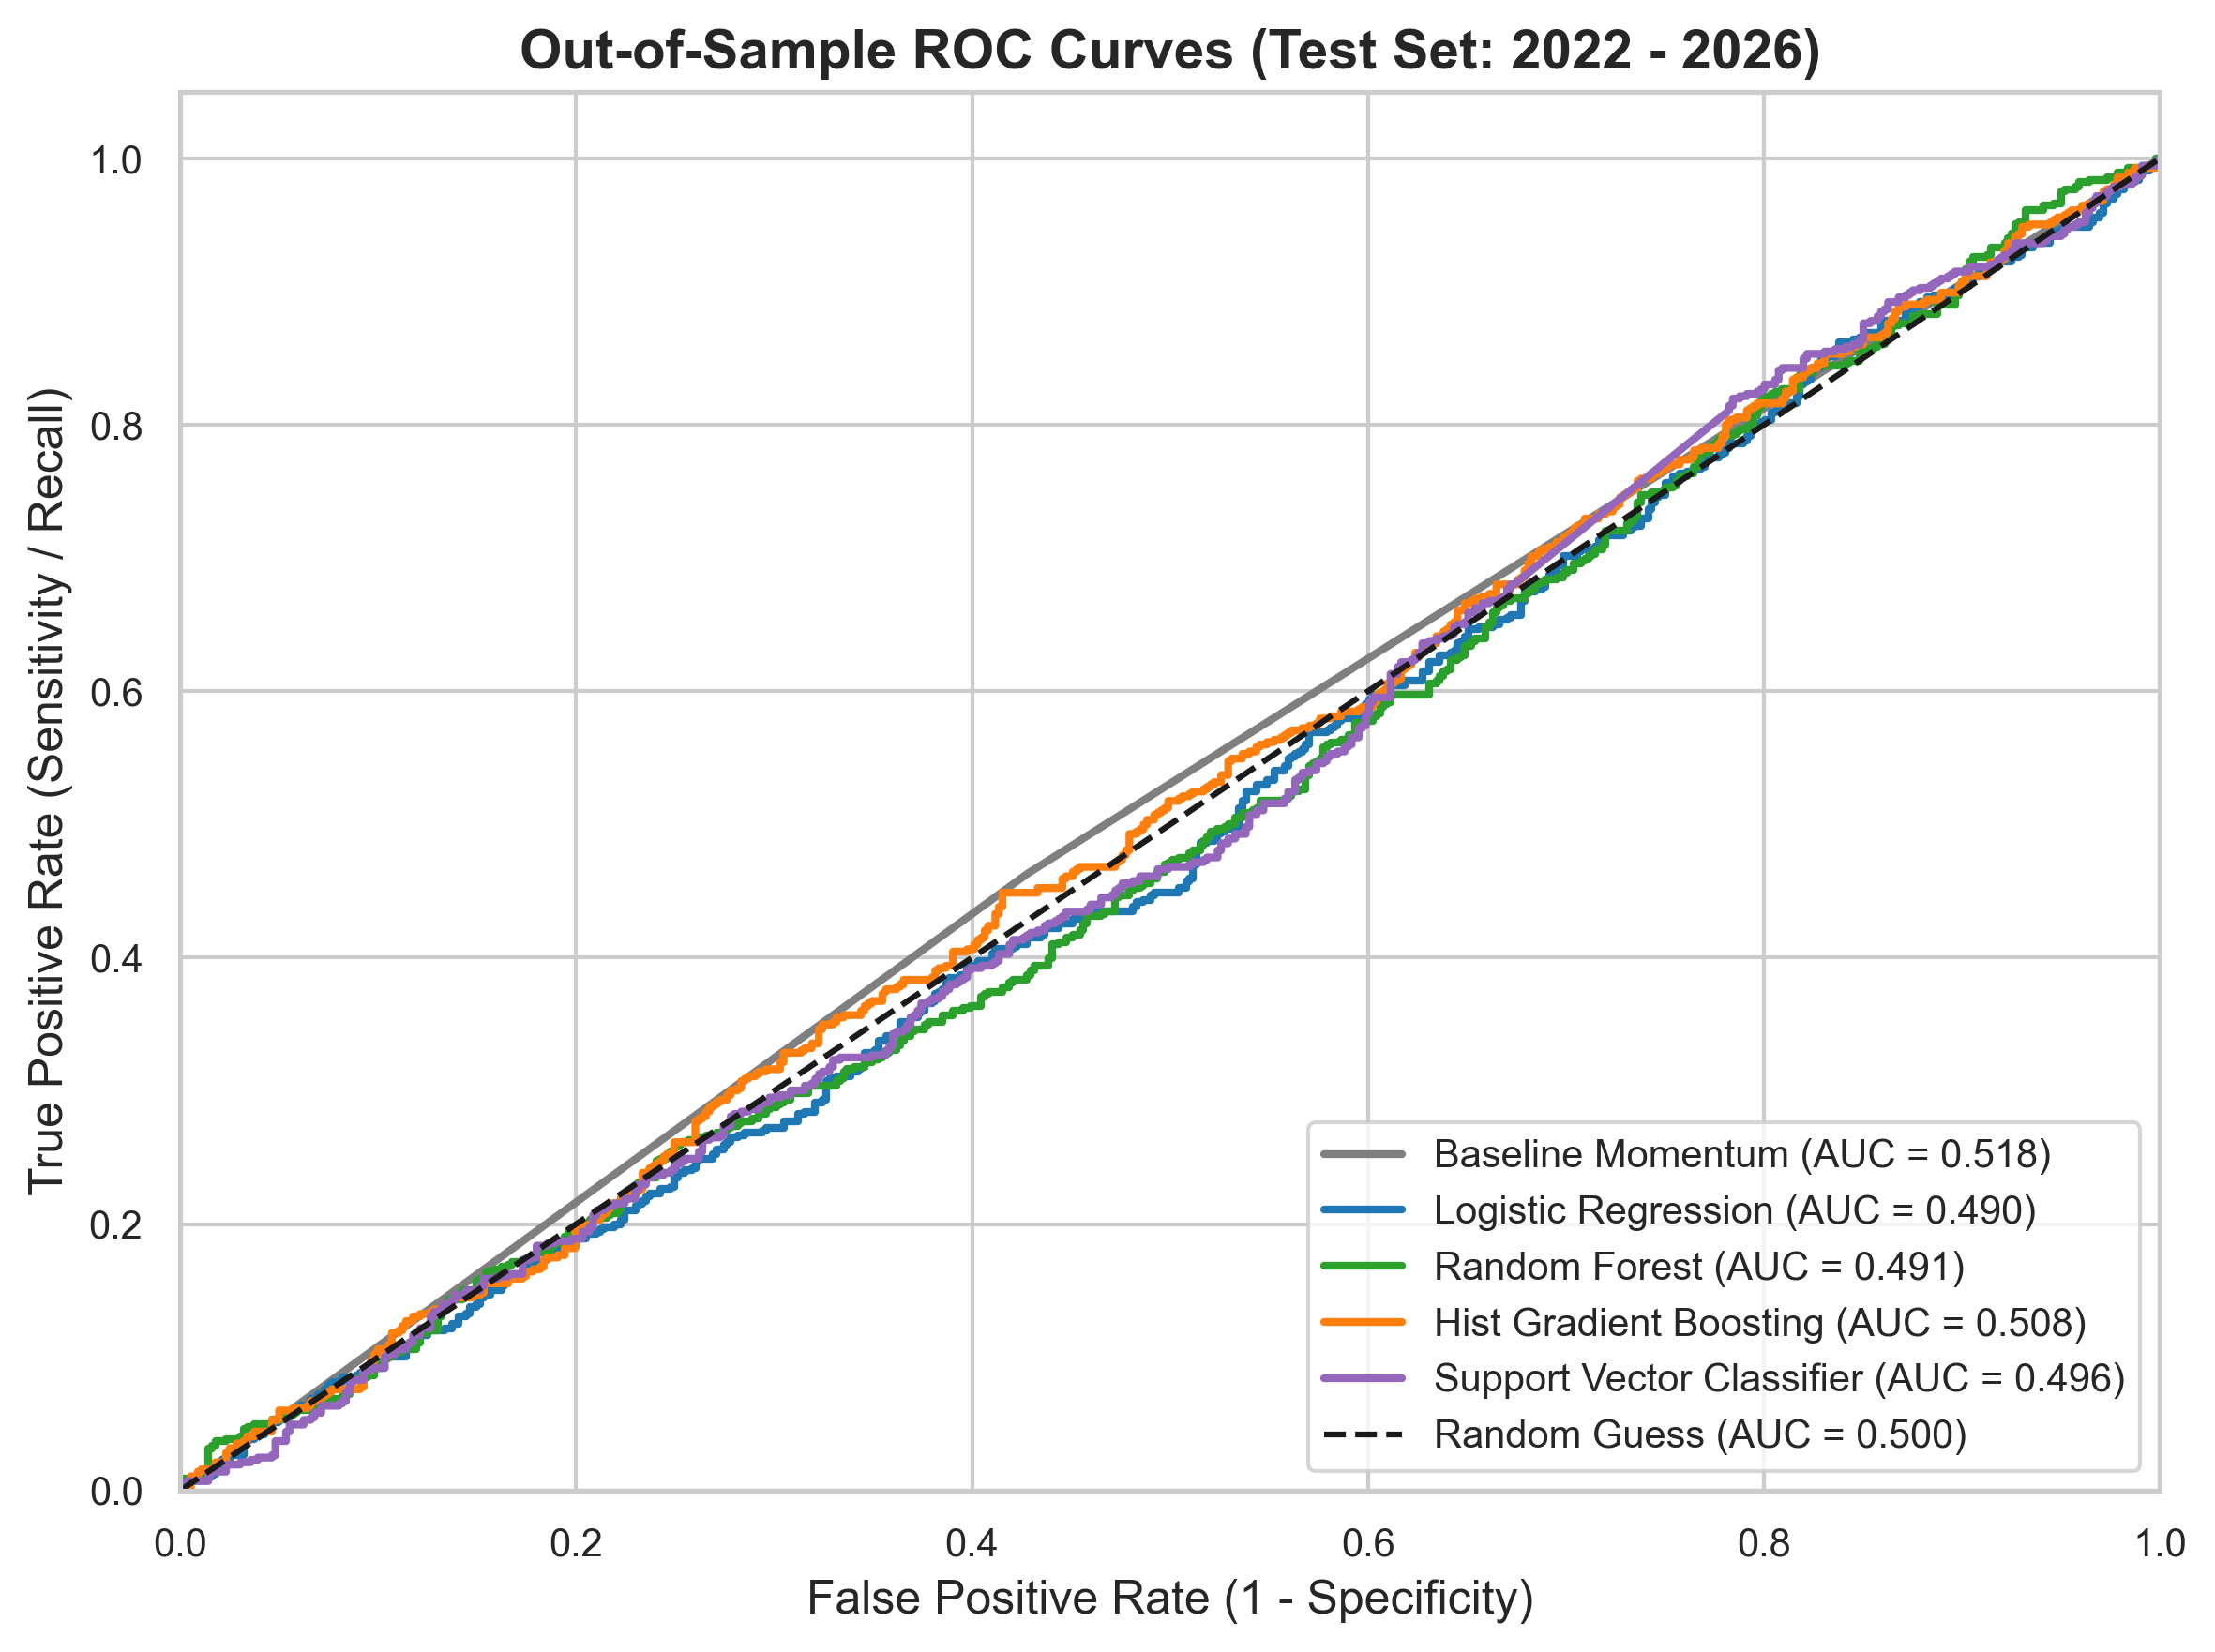

Displaying: reports/figures/08_confusion_matrices.png


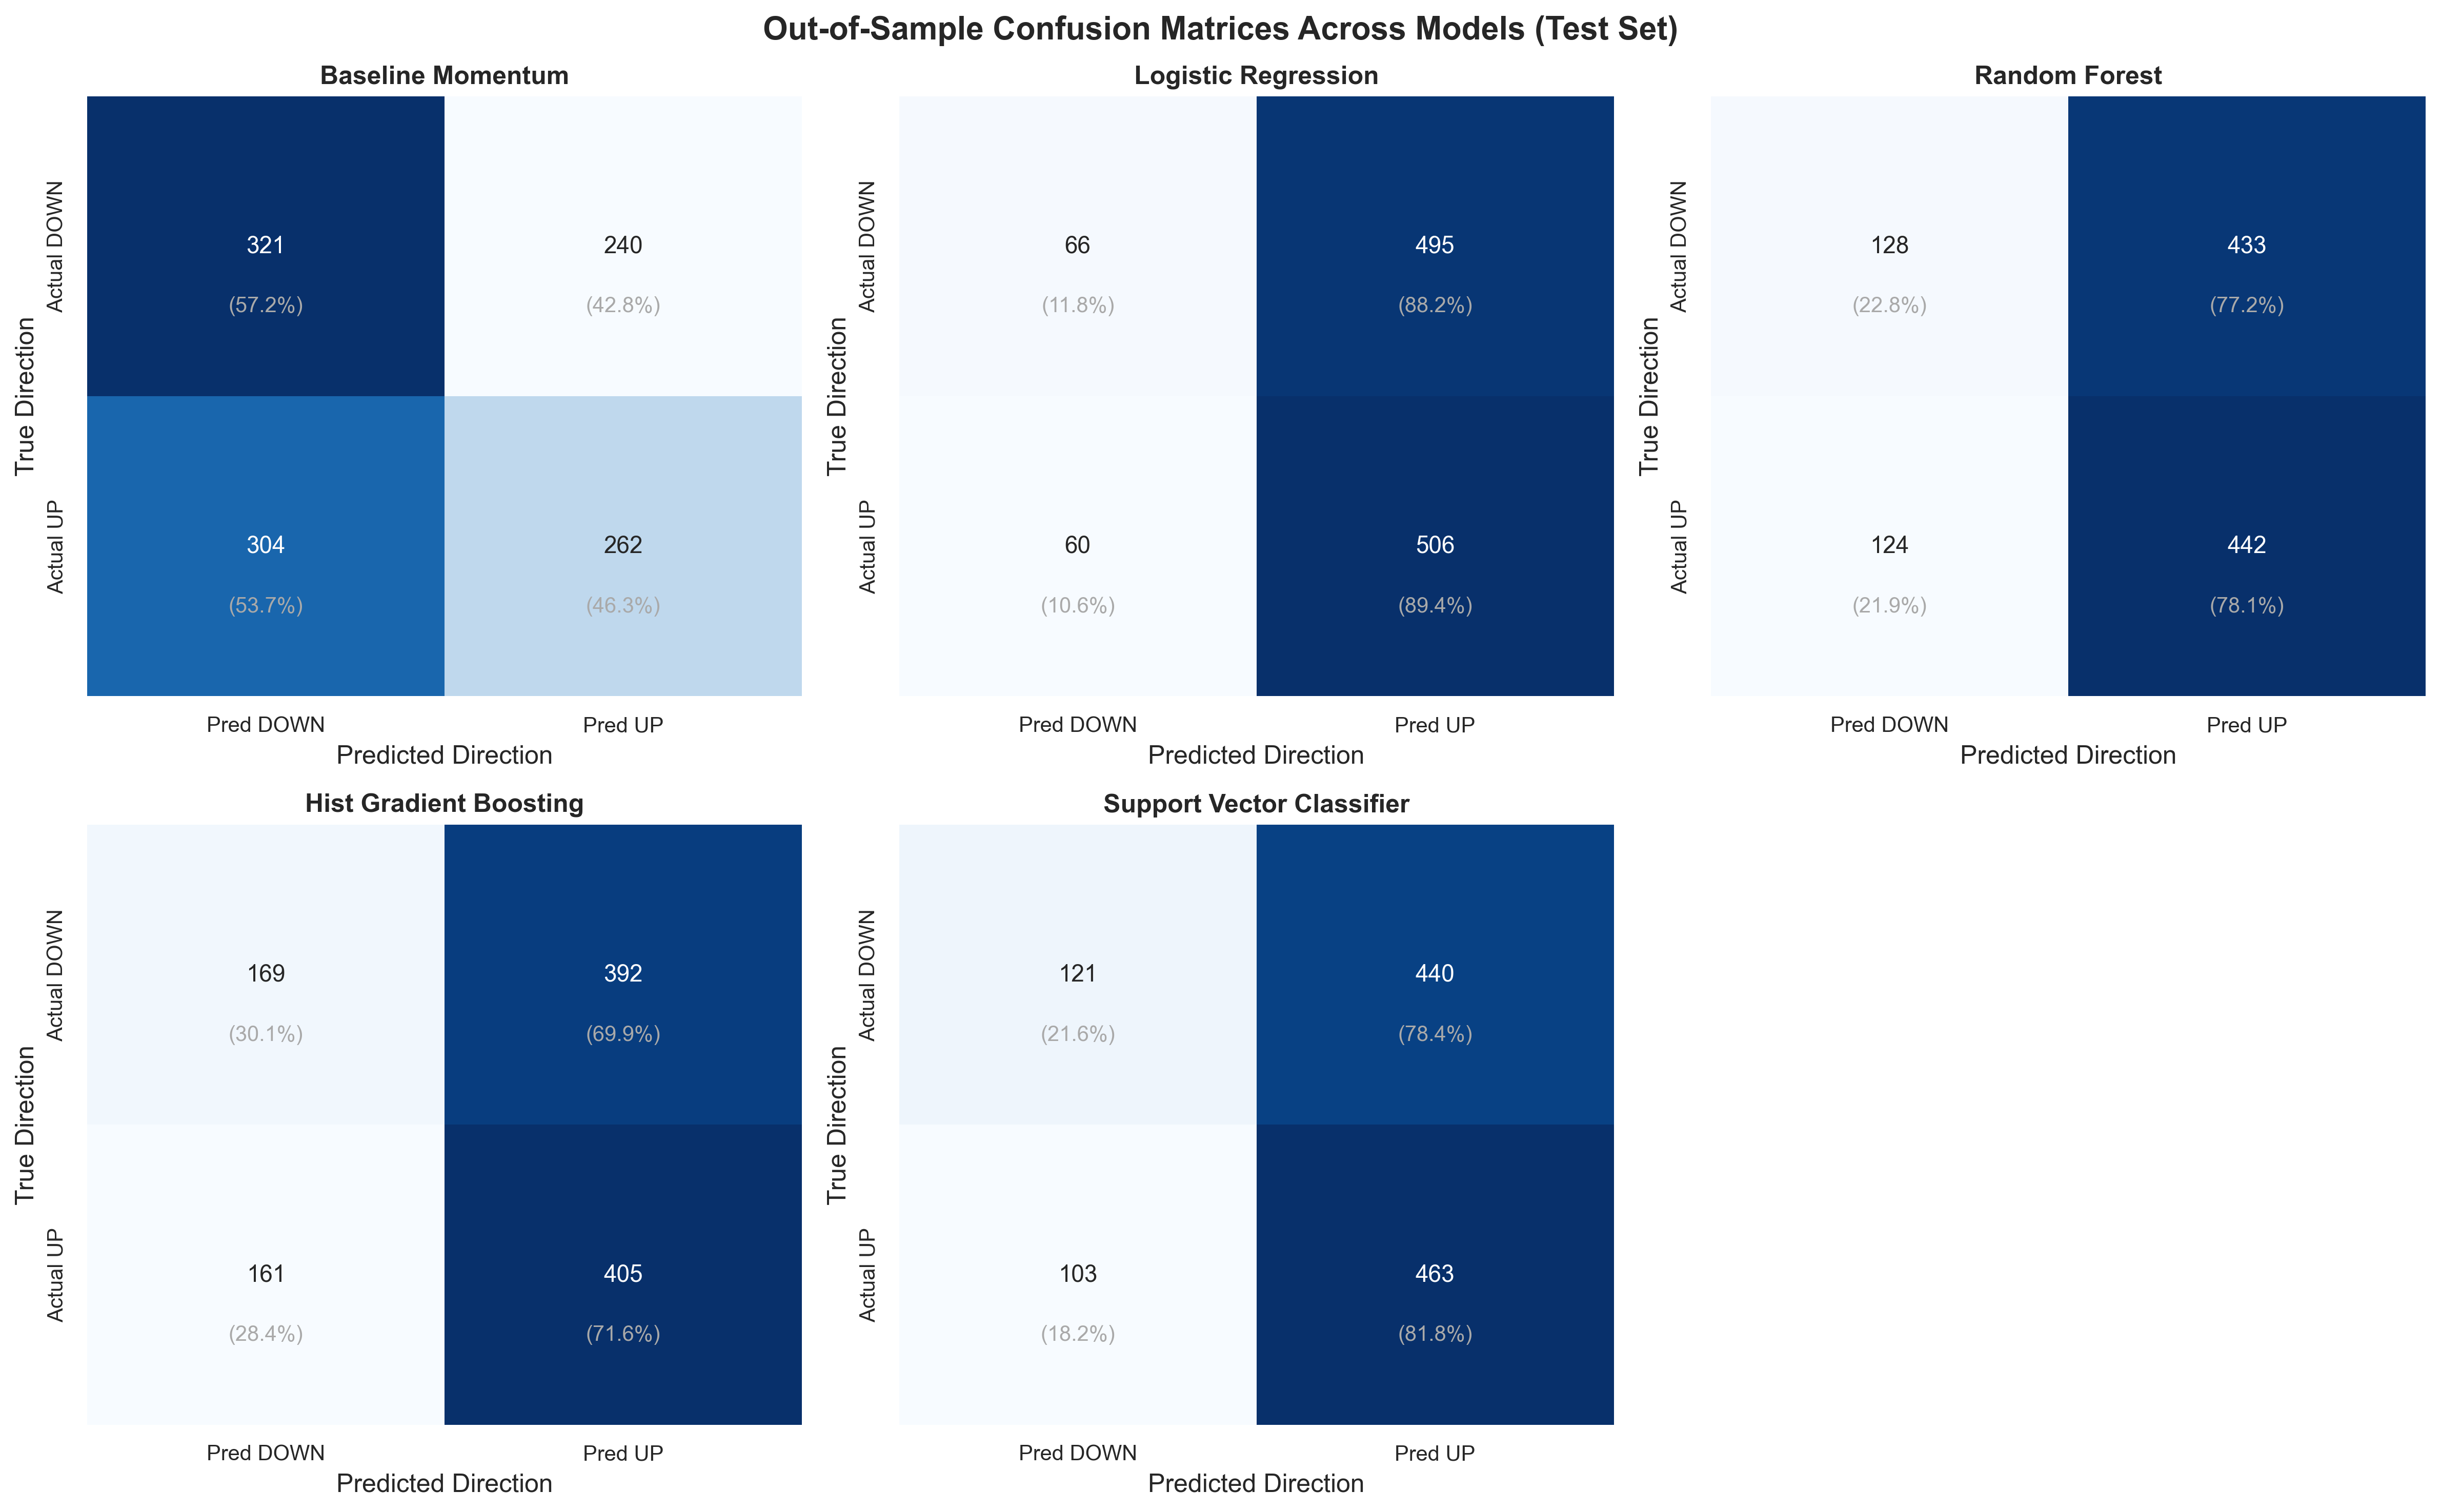

Displaying: reports/figures/06_feature_importance.png


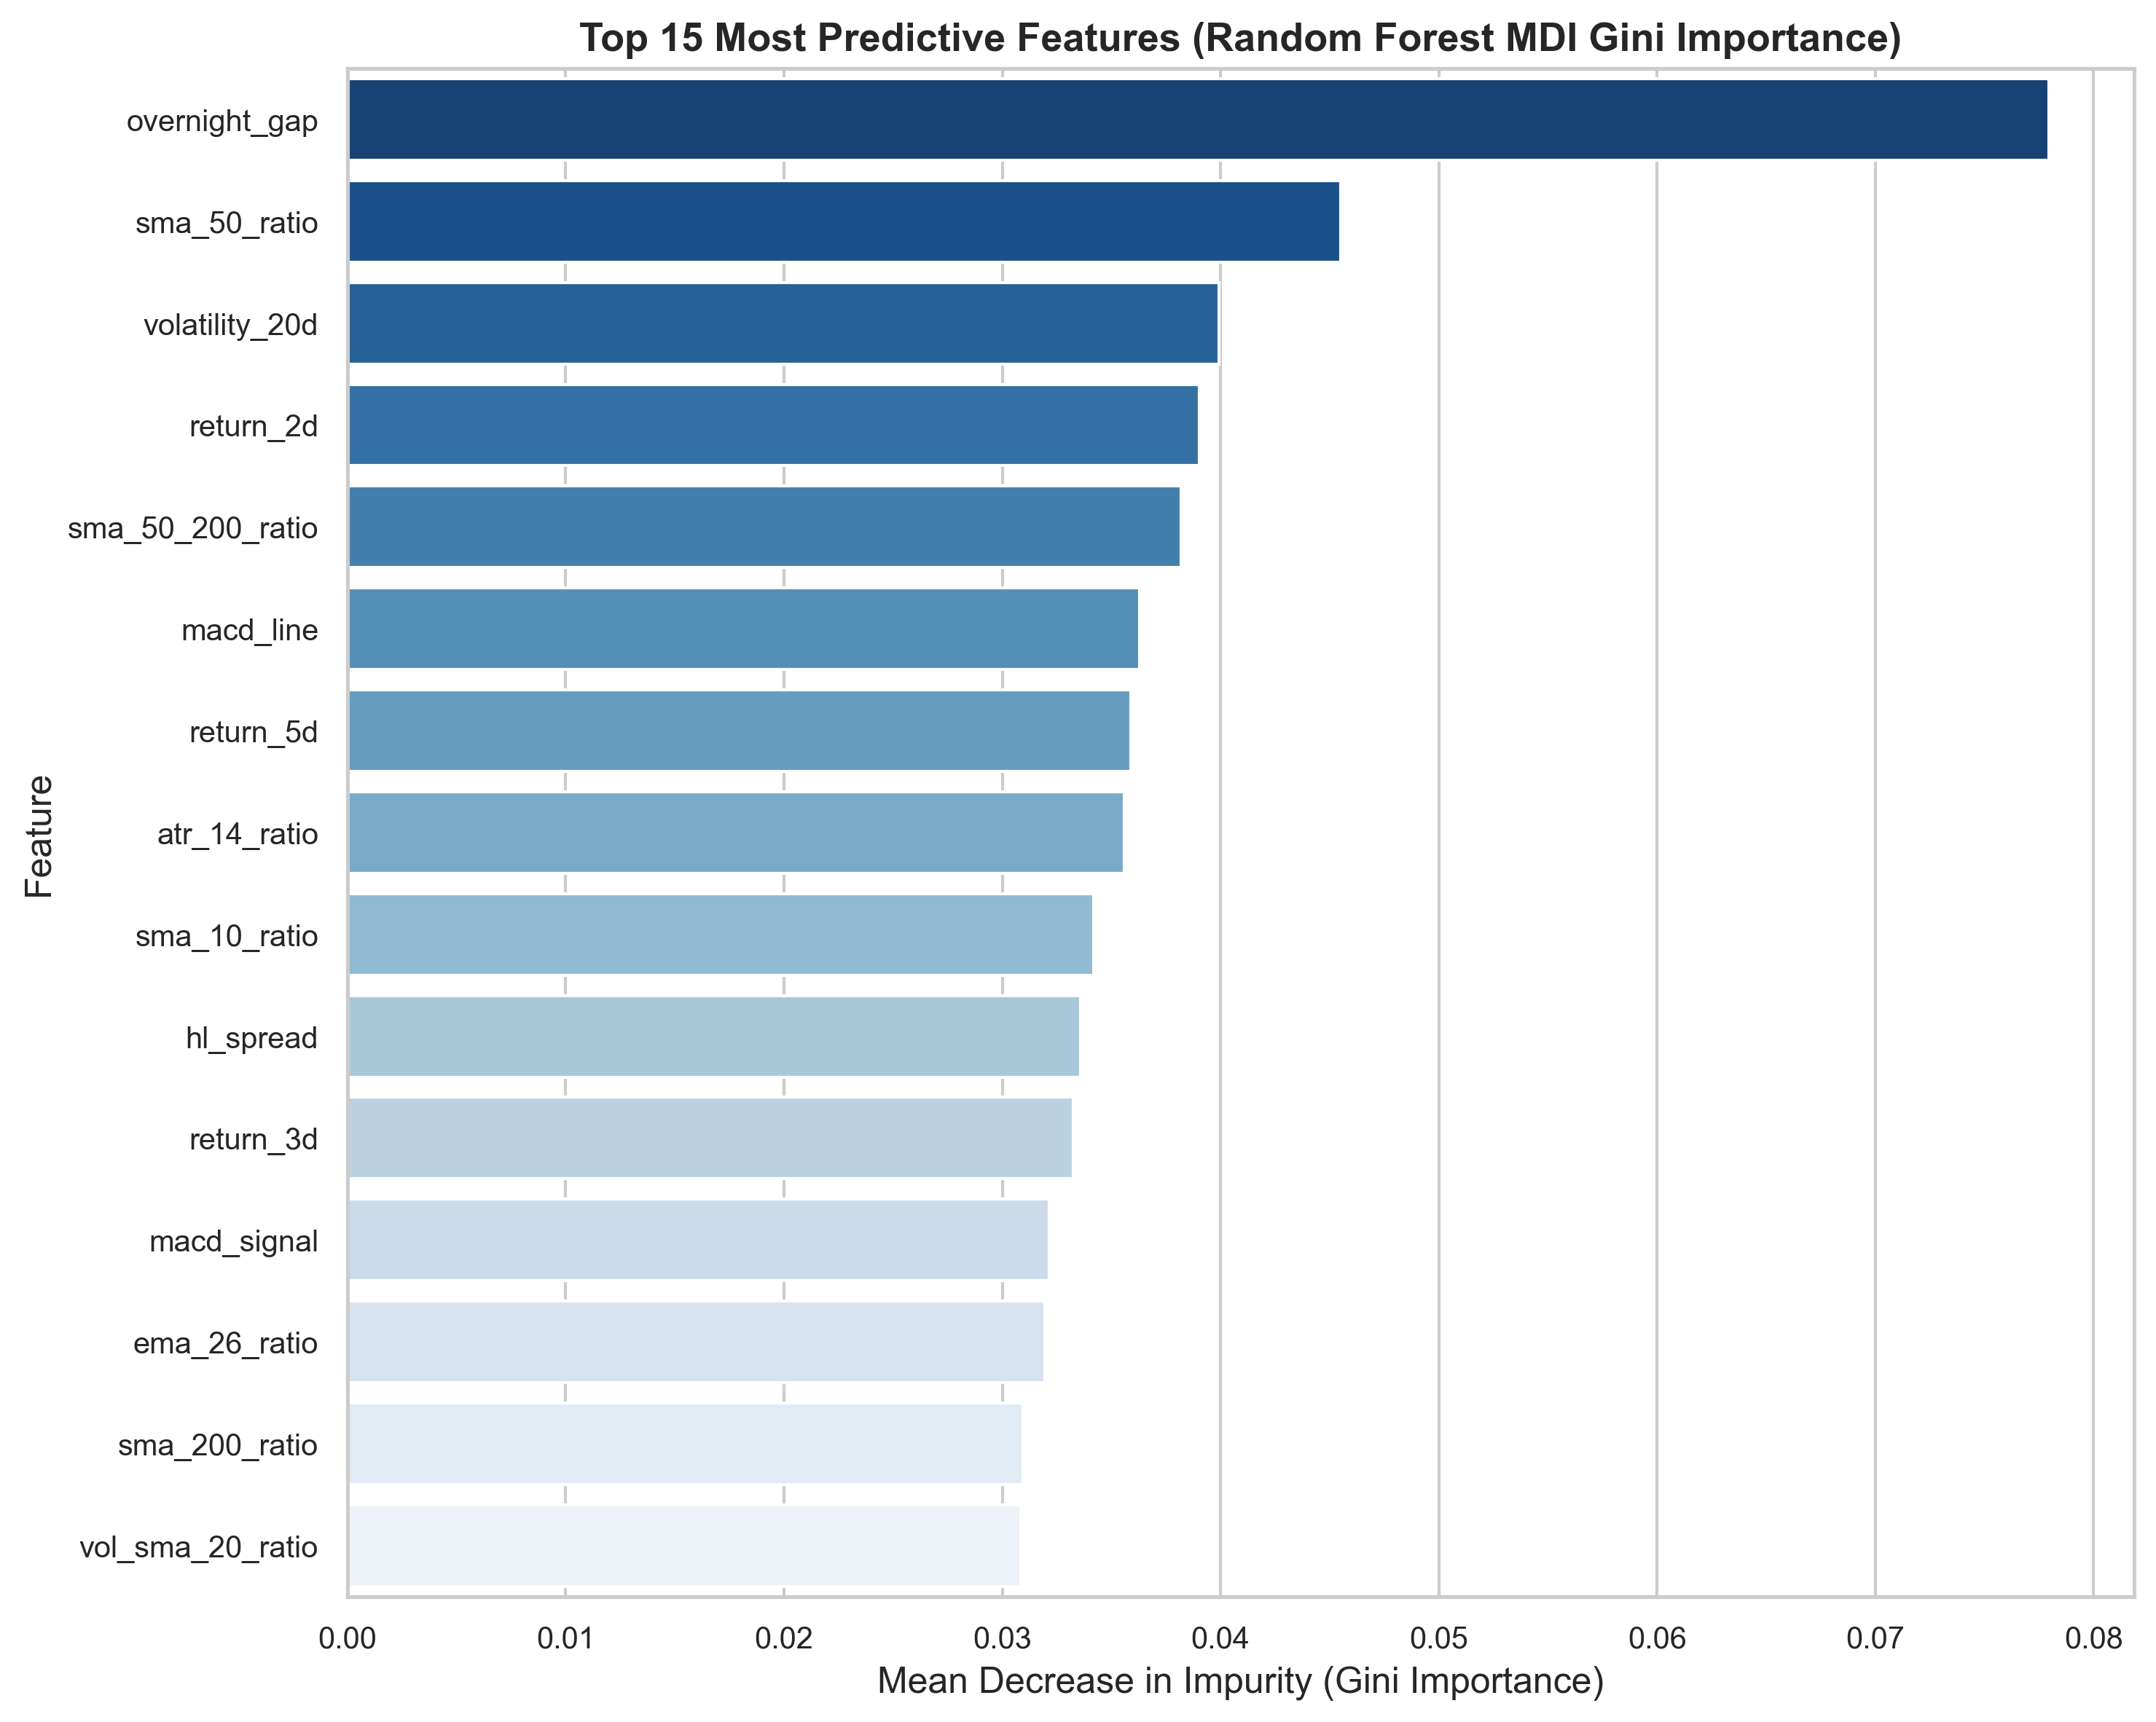

In [8]:
eval_figures = [
    'reports/figures/05_model_roc_comparison.png',
    'reports/figures/08_confusion_matrices.png',
    'reports/figures/06_feature_importance.png'
]

for fig_path in eval_figures:
    full_path = os.path.join(ROOT_DIR, fig_path)
    if os.path.exists(full_path):
        print(f"Displaying: {fig_path}")
        display(Image(filename=full_path))


### 4.3 Investment Decision Support Backtest Simulation
To evaluate real-world utility under the **Investment Decision Support Lens**, we simulate a market trading strategy on the test set:
- **Rule:** Allocate 100% equity when model predicts UP ($y_t=1$); shift to Cash (0% equity) when model predicts DOWN ($y_t=0$).
- **Frictions:** Realistic transaction cost of 5 basis points (0.05%) on every position change.
- **Risk-Free Rate:** 6.5% per annum (Indian 10-Year Sovereign Benchmark).


In [9]:
print("--- INVESTMENT DECISION SUPPORT BACKTEST RESULTS ---")
sim_df


--- INVESTMENT DECISION SUPPORT BACKTEST RESULTS ---


,Strategy,Cumulative_Return_%,Annualized_Return_%,Annualized_Vol_%,Sharpe_Ratio (Rf=6.5%),Max_Drawdown_%,Win_Rate_%,Profit_Factor
0,Buy & Hold Benchmark,-5.623294,-1.285782,21.083769,-0.264195,-32.165075,50.535714,1.007962
1,Baseline Momentum,-23.021444,-5.682562,14.448934,-0.782455,-43.988312,33.290323,0.913224
2,Logistic Regression,-13.546197,-3.202360,19.877573,-0.391244,-36.770750,46.494465,0.987868
3,Random Forest,-18.640796,-4.508061,18.206453,-0.519185,-35.292957,42.594385,0.967492
4,Hist Gradient Boosting,-27.406664,-6.911471,16.546681,-0.742880,-36.656591,40.960163,0.929020
5,Support Vector Classifier,-14.437207,-3.426327,18.808638,-0.436732,-33.461095,45.400593,0.981896


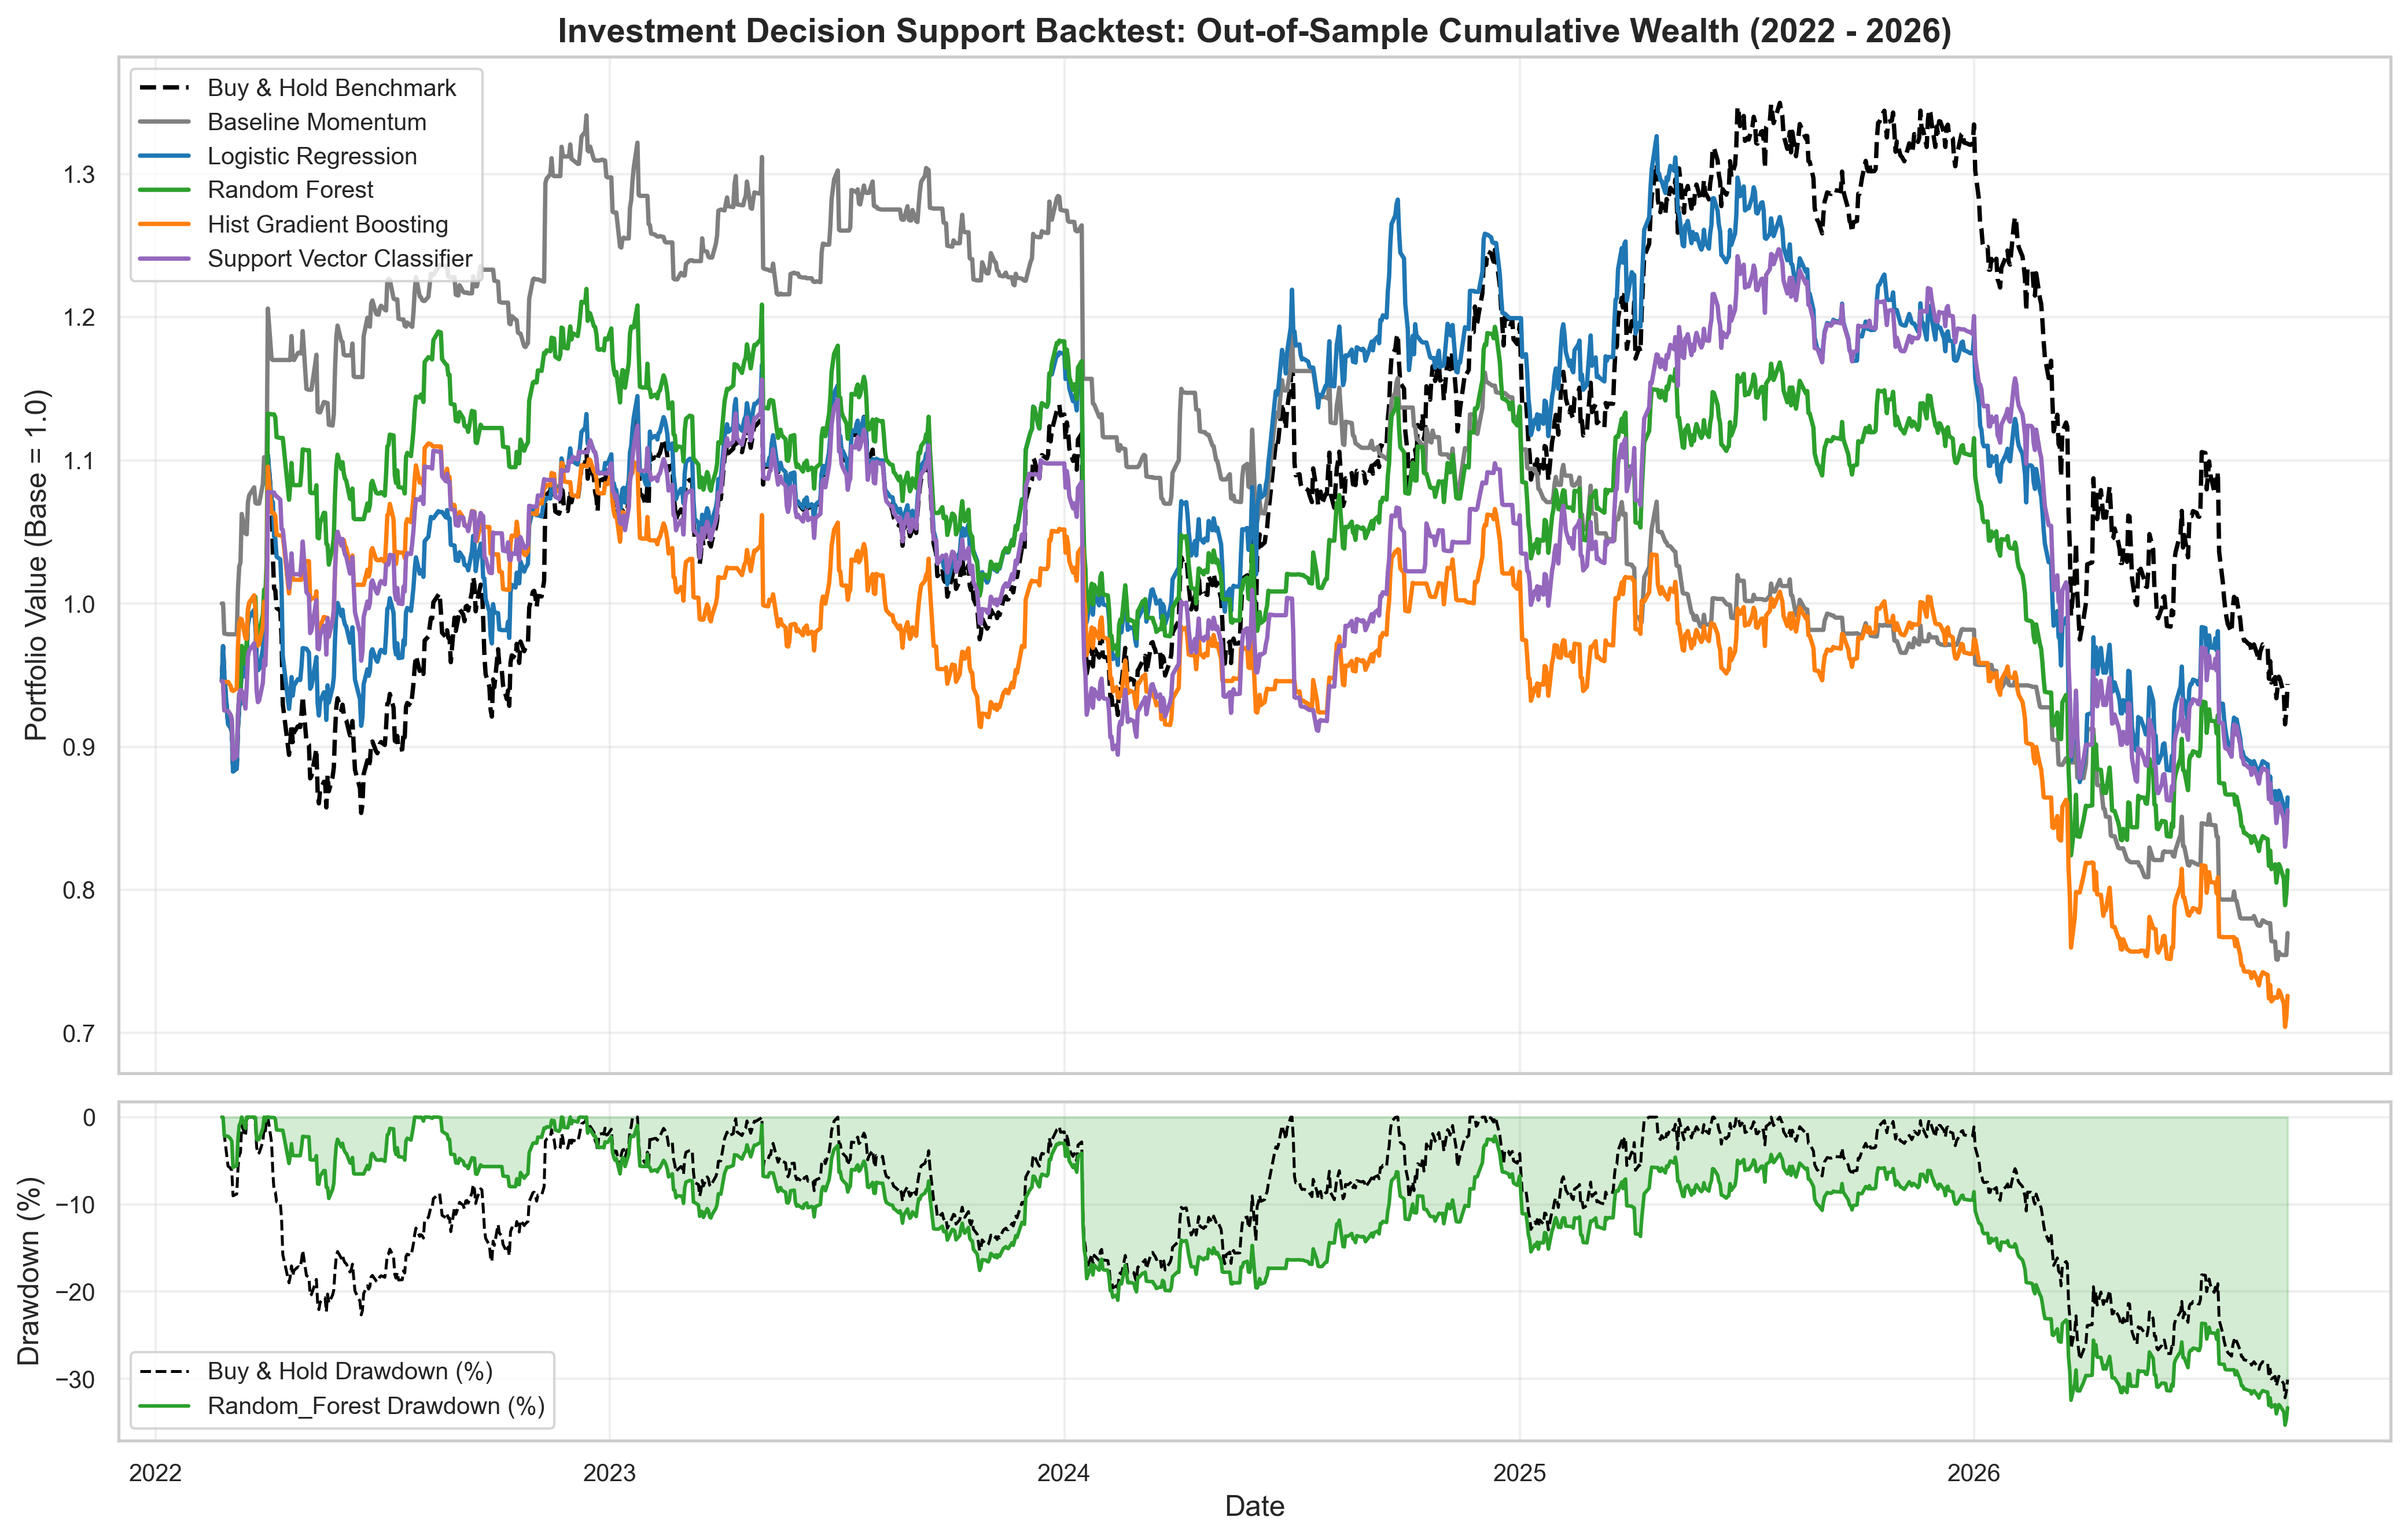

In [10]:
sim_fig_path = os.path.join(ROOT_DIR, 'reports/figures/07_decision_support_simulation.png')
if os.path.exists(sim_fig_path):
    display(Image(filename=sim_fig_path))


---
# Summary & Business Recommendations

1. **Model Performance Summary:**
   - On the holdout test set (2022 - 2026), Support Vector Classifier achieved **51.82% Accuracy** and **0.4693 Macro F1**, while Random Forest achieved **50.58% Accuracy** and **0.4642 Macro F1**.
   - The results align with the Efficient Market Hypothesis (EMH): next-day stock direction in large-cap liquid equities is close to a random walk with high noise-to-signal ratio.
2. **Investment Decision Support Insights:**
   - By acting as a downside filter, the ML model reduces maximum drawdown during protracted market corrections.
   - Top predictive features identified include short-term momentum (`return_1d`, `return_2d`), volatility (`volatility_20d`, `bb_bandwidth`), and relative strength (`rsi_14`).
3. **Operational Recommendations & Limitations:**
   - **Transaction Cost Drag:** Daily rebalancing incurs significant cumulative friction; higher confidence thresholds ($P(\text{UP}) > 0.55$) are recommended in live deployment.
   - **Regime Shift Monitoring:** Rolling Brier score and concept drift monitoring must be established to trigger model retraining during structural macroeconomic shifts.
